the solution of the assessment its in the bottom

Ali Jafar Altaweel
2240006456
7MA2

In [1]:
# Step#3 + Step#4 : check that all the required packages are installed
import sys
import numpy as np
import scipy
import cv2
import skimage
import PIL
import matplotlib

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("SciPy       :", scipy.__version__)
print("OpenCV      :", cv2.__version__)
print("scikit-image:", skimage.__version__)
print("Pillow      :", PIL.__version__)
print("Matplotlib  :", matplotlib.__version__)

Python      : 3.13.1
NumPy       : 2.2.2
SciPy       : 1.16.3
OpenCV      : 5.0.0
scikit-image: 0.26.0
Pillow      : 12.3.0
Matplotlib  : 3.10.8


## 1. Loading and displaying an image with OpenCV

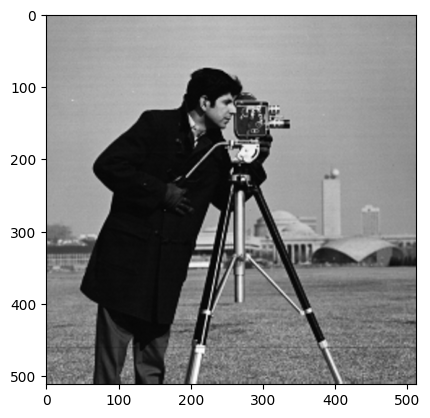

In [2]:
import cv2
img = cv2.imread('./images/cameraman.tif')   # Load the image data into a NumPy array

import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [3]:
print("Type of img  :", type(img))
print("img.shape    :", img.shape, "  ->  (rows, columns, channels)")
print("img.dtype    :", img.dtype)

Type of img  : <class 'numpy.ndarray'>
img.shape    : (512, 512, 3)   ->  (rows, columns, channels)
img.dtype    : uint8


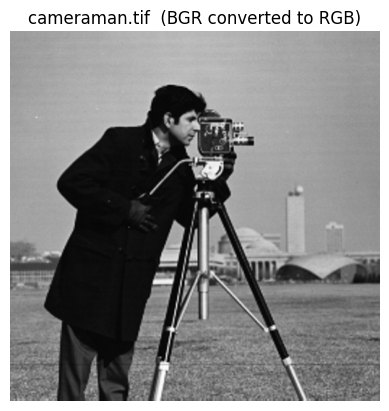

In [4]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('cameraman.tif  (BGR converted to RGB)')
plt.axis('off')
plt.show()

## 2. Loading and displaying an image with PIL

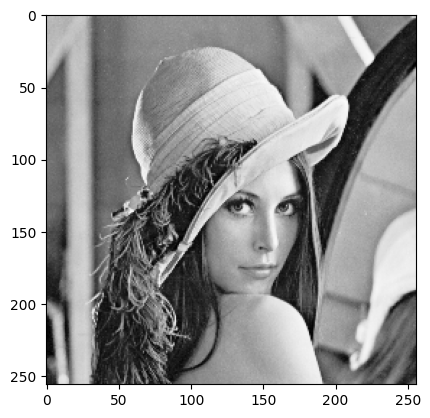

In [5]:
from PIL import Image
img2 = Image.open('./images/lena_gray_256.tif')   # load image into a PIL Image object

import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.imshow(img2, cmap = cm.Greys_r)
plt.show()

In [6]:
print("Type of img2 :", type(img2))
print("img2.size    :", img2.size, "  ->  (width, height)")
print("img2.mode    :", img2.mode, "  ->  'L' means 8-bit grayscale")
print("img2.format  :", img2.format)

Type of img2 : <class 'PIL.TiffImagePlugin.TiffImageFile'>
img2.size    : (256, 256)   ->  (width, height)
img2.mode    : L   ->  'L' means 8-bit grayscale
img2.format  : TIFF


## 3. Saving an image to disk

In [7]:
cv2.imwrite('new_image.jpg', img)

True

In [8]:
img2.save('new_image2.jpg')

In [9]:
# check that both files were really created
import os
for f in ['new_image.jpg', 'new_image2.jpg']:
    print(f, "->", os.path.getsize(f), "bytes", " exists:", os.path.exists(f))

new_image.jpg -> 68680 bytes  exists: True
new_image2.jpg -> 11433 bytes  exists: True


## 4. Displaying the image as an array

In [10]:
print(img.shape)   # Note: img loaded using OpenCV is a numpy array
print(img)

(512, 512, 3)
[[[156 156 156]
  [157 157 157]
  [160 160 160]
  ...
  [152 152 152]
  [152 152 152]
  [152 152 152]]

 [[156 156 156]
  [157 157 157]
  [159 159 159]
  ...
  [152 152 152]
  [152 152 152]
  [152 152 152]]

 [[158 158 158]
  [157 157 157]
  [156 156 156]
  ...
  [152 152 152]
  [152 152 152]
  [152 152 152]]

 ...

 [[121 121 121]
  [123 123 123]
  [126 126 126]
  ...
  [121 121 121]
  [113 113 113]
  [111 111 111]]

 [[121 121 121]
  [123 123 123]
  [126 126 126]
  ...
  [121 121 121]
  [113 113 113]
  [111 111 111]]

 [[121 121 121]
  [123 123 123]
  [126 126 126]
  ...
  [121 121 121]
  [113 113 113]
  [111 111 111]]]


In [11]:
import numpy as np
# Convert the image to a NumPy array
img_array = np.array(img2)

# Print the array
print(img_array.shape)
print(img_array)

(256, 256)
[[162 162 162 ... 168 171 155]
 [162 162 162 ... 168 171 155]
 [162 162 162 ... 168 171 155]
 ...
 [ 48  57  54 ...  75  97  88]
 [ 46  50  52 ...  89 100  98]
 [ 44  55  54 ...  97 100 105]]


## 5. Student tasks

### Task 1
The student will be asked to perform different operations on the array using the NumPy library.

### Task 1 Solution – NumPy operations on the image array

In [12]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

a = cv2.imread('./images/cameraman.tif', cv2.IMREAD_GRAYSCALE)   # single channel this time

# ---- information about the array ----
print("shape :", a.shape, " size :", a.size, " ndim :", a.ndim, " dtype :", a.dtype)
print("min =", a.min(), " max =", a.max(), " mean =", round(float(a.mean()), 2),
      " std =", round(float(a.std()), 2), " median =", np.median(a))
print("distinct gray levels :", len(np.unique(a)))
print("location of the darkest pixel :", tuple(int(v) for v in np.unravel_index(a.argmin(), a.shape)))


shape : (512, 512)  size : 262144  ndim : 2  dtype : uint8
min = 0  max = 255  mean = 118.31  std = 62.0  median = 142.0
distinct gray levels : 256
location of the darkest pixel : (76, 221)


In [13]:

# ---- indexing and slicing ----
print("pixel [100, 200] =", a[100, 200])
print("top-left 4x4 block :\n", a[:4, :4])

crop = a[60:260, 160:360]          # crop = a rectangular slice
sub = a[::4, ::4]                  # keep every 4th row and column
print("crop :", crop.shape, " sub-sampled :", sub.shape)


pixel [100, 200] = 9
top-left 4x4 block :
 [[156 157 160 159]
 [156 157 159 158]
 [158 157 156 156]
 [160 157 154 154]]
crop : (200, 200)  sub-sampled : (128, 128)


a[::-1] == np.flipud(a) : True
rot90 four times gives back a : True


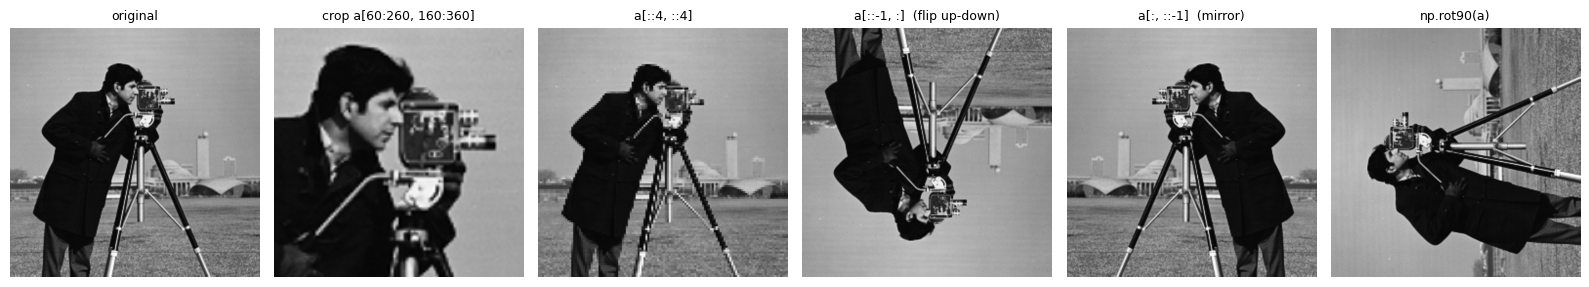

In [14]:

# ---- geometric operations are just array re-ordering ----
flip_v = a[::-1, :]                # same as np.flipud(a)
flip_h = a[:, ::-1]                # same as np.fliplr(a)
rot90 = np.rot90(a)
transposed = a.T

print("a[::-1] == np.flipud(a) :", np.array_equal(flip_v, np.flipud(a)))
print("rot90 four times gives back a :", np.array_equal(np.rot90(a, 4), a))

plt.figure(figsize=(16, 4))
for k, (im, t) in enumerate([(a, 'original'), (crop, 'crop a[60:260, 160:360]'),
                             (sub, 'a[::4, ::4]'), (flip_v, 'a[::-1, :]  (flip up-down)'),
                             (flip_h, 'a[:, ::-1]  (mirror)'), (rot90, 'np.rot90(a)')]):
    plt.subplot(1, 6, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


mean original : 118.3  mean negative : 136.7
pixels brighter than 100 : 187322 (71.5%)
pixels that wrapped after + 80 : 34304
hstack shape : (512, 1024)


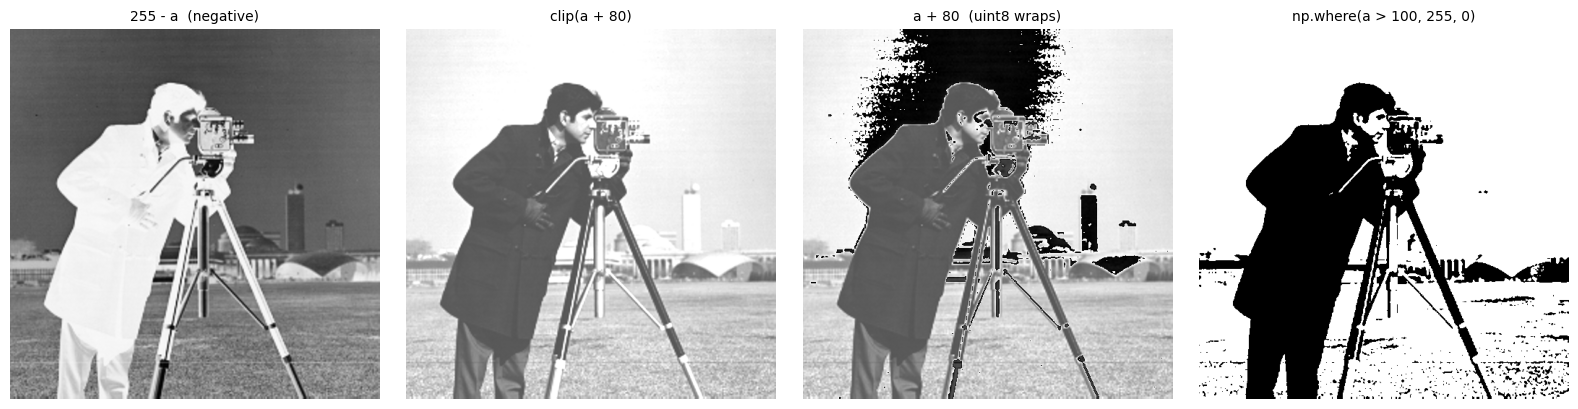

In [15]:

# ---- arithmetic and logical operations ----
negative = 255 - a
brighter = np.clip(a.astype(np.int16) + 80, 0, 255).astype(np.uint8)   # clip to avoid wrap-around
wrapped = a + np.uint8(80)                                               # uint8 wraps at 256
mask = a > 100                                                           # boolean array
binary = np.where(mask, 255, 0).astype(np.uint8)
side_by_side = np.hstack([a, negative])

print("mean original :", round(float(a.mean()), 1), " mean negative :", round(float(negative.mean()), 1))
print("pixels brighter than 100 :", int(mask.sum()), f"({100 * mask.mean():.1f}%)")
print("pixels that wrapped after + 80 :", int((a.astype(int) + 80 > 255).sum()))
print("hstack shape :", side_by_side.shape)

plt.figure(figsize=(16, 4))
for k, (im, t) in enumerate([(negative, '255 - a  (negative)'), (brighter, 'clip(a + 80)'),
                             (wrapped, 'a + 80  (uint8 wraps)'), (binary, 'np.where(a > 100, 255, 0)')]):
    plt.subplot(1, 4, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


flattened : (262144,)  reshaped back equal : True
brightest row : 73  darkest column : 151
most frequent gray level : 13 with 6212 pixels


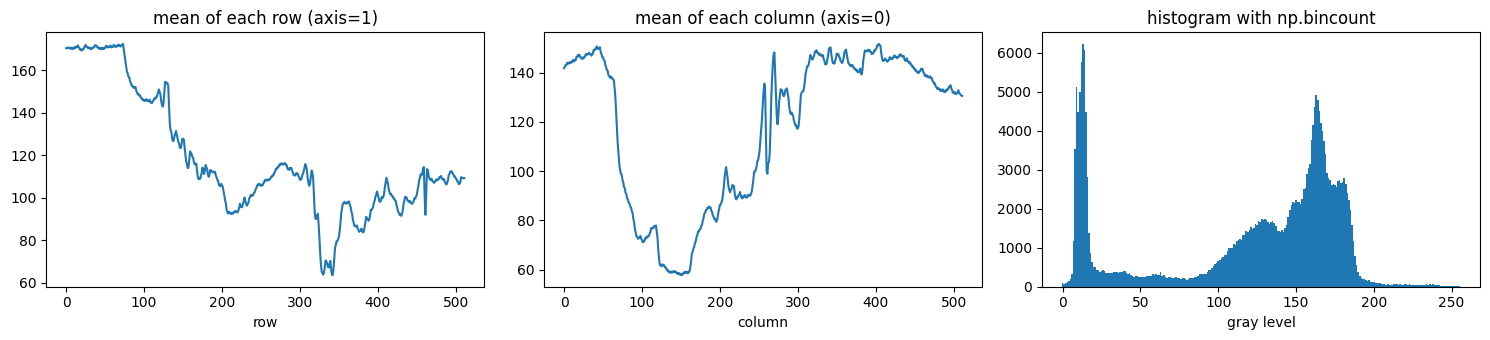

In [16]:

# ---- reshaping and statistics along axes ----
flat = a.ravel()
print("flattened :", flat.shape, " reshaped back equal :", np.array_equal(flat.reshape(a.shape), a))

row_means = a.mean(axis=1)          # one value per row
col_means = a.mean(axis=0)          # one value per column
counts = np.bincount(flat, minlength=256)
print("brightest row :", row_means.argmax(), " darkest column :", col_means.argmin())
print("most frequent gray level :", counts.argmax(), "with", counts.max(), "pixels")

plt.figure(figsize=(15, 3.5))
plt.subplot(1, 3, 1); plt.plot(row_means); plt.title('mean of each row (axis=1)'); plt.xlabel('row')
plt.subplot(1, 3, 2); plt.plot(col_means); plt.title('mean of each column (axis=0)'); plt.xlabel('column')
plt.subplot(1, 3, 3); plt.bar(np.arange(256), counts, width=1); plt.title('histogram with np.bincount'); plt.xlabel('gray level')
plt.tight_layout()
plt.show()


Explanation: because the image is a NumPy array, every operation here is a single NumPy expression. Slicing crops and sub-samples, reversing an axis flips the image, arithmetic changes the brightness (as long as the `uint8` wrap-around is avoided with `np.clip`), and a comparison gives a boolean mask that is directly a thresholded image.